# 07 — M2: Telemetry LSTM Baseline

**CAN-bus-only baseline** — 5 vehicle telemetry signals @ 4 Hz

Signals: `pitch[deg]`, `roll[deg]`, `speed[m/s]`, `rpm`, `gear`

Architecture: `Input(240,5) → LSTM(64) → Drop → LSTM(32) → Drop → Dense(32) → BN → Dense(3,softmax)`

**Note:** Subject A has no Telemetry data — excluded from Fold 0.

In [1]:

import sys, warnings, os
from pathlib import Path
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

ROOT    = Path('..').resolve()
_nb_dir = Path(__file__).resolve().parent if '__file__' in dir() else Path().resolve()

# ── Prevent notebooks/models/ from shadowing src/models/ ─────────────────────
sys.path = [p for p in sys.path if Path(p).resolve() != _nb_dir]
sys.path.insert(0, str(ROOT / 'src'))

# Clear any stale module cache from previous runs
for _key in list(sys.modules.keys()):
    if _key in ('models', 'models.architecture', 'models.train',
                'utils', 'utils.helpers', 'data', 'data.load_data'):
        del sys.modules[_key]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
%matplotlib inline

from models.architecture import build_model
from models.train         import cross_validate
from utils.helpers        import (
    plot_training_history,
    plot_confusion_matrix,
    plot_fold_results,
)

FOLD_DIR   = ROOT / 'datasets' / 'processed' / 'ul_dd'
CKPT_DIR   = ROOT / 'models' / 'checkpoints'
CKPT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME  = 'M2'
CLASS_NAMES = ['Alert', 'LowVigilant', 'Drowsy']
print(f'ROOT     : {ROOT}')
print(f'FOLD_DIR : {FOLD_DIR}')
print(f'CKPT_DIR : {CKPT_DIR}')
print('Ready.')


ROOT     : C:\Users\raka1005\Documents\IISC\driver-drowsiness-detection-system
FOLD_DIR : C:\Users\raka1005\Documents\IISC\driver-drowsiness-detection-system\datasets\processed\ul_dd
CKPT_DIR : C:\Users\raka1005\Documents\IISC\driver-drowsiness-detection-system\models\checkpoints
Ready.


In [2]:
# ── Architecture summary ──────────────────────────────────────────────────────
build_model('m2').summary()

Model: "M2_TelemetryLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tele_input (InputLayer)         │ (None, 240, 5)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 240, 64)        │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 240, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,619 (123.51 KB)

 Trainable params: 31,555 (123.26 KB)

 Non-trainable params: 64 (256.00 B)

In [3]:

# ── Inspect available keys in fold files ──────────────────────────────────────
sample_fold = sorted(Path(FOLD_DIR).glob('fold_*.npz'))
if sample_fold:
    with np.load(sample_fold[0], allow_pickle=True) as f:
        print('Available keys in fold file:', list(f.keys()))

# ── 5-Fold Cross-Validation ───────────────────────────────────────────────────
# Improvements vs v1:
#   • save_dir explicitly set to CKPT_DIR
#   • epochs=200  + es_patience=25
#   • learning_rate=5e-4
#   • class_weight applied automatically inside train_fold
results = cross_validate(
    model_fn      = lambda: build_model('m2'),
    model_name    = MODEL_NAME,
    fold_dir      = str(FOLD_DIR),
    input_keys    = ('mm_tele_train', 'mm_tele_test'),
    label_keys    = ('mm_y_train', 'mm_y_test'),
    save_dir      = str(CKPT_DIR),
    epochs        = 200,
    batch_size    = 32,
    learning_rate = 5e-4,
    es_patience   = 25,
)

print(f'\n=== M2 Results ===')
print(f'Accuracy : {results["mean_acc"]:.4f} ± {results["std_acc"]:.4f}')
print(f'Macro-F1 : {results["mean_f1"]:.4f}  ± {results["std_f1"]:.4f}')


Available keys in fold file: ['test_subjects', 'X_fau_train', 'X_fau_test', 'y_train', 'y_test', 'mm_fau_train', 'mm_tele_train', 'mm_y_train', 'mm_fau_test', 'mm_tele_test', 'mm_y_test', 'fau_mean', 'fau_std', 'tele_mean', 'tele_std']

  Cross-Validation: M2  (5 folds)

  Fold 0 | test_subjects = ['A' 'B' 'C' 'D']
  [Fold 0] class_weights = {0: 1.0649801587301588, 1: 1.0618199802176063, 2: 0.8934665002080733}
Epoch 1/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - accuracy: 0.3530 - loss: 1.2592 - val_accuracy: 0.2636 - val_loss: 1.1330 - learning_rate: 5.0000e-04
Epoch 2/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step - accuracy: 0.3664 - loss: 1.1680 - val_accuracy: 0.2496 - val_loss: 1.1391 - learning_rate: 5.0000e-04
Epoch 3/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - accuracy: 0.3711 - loss: 1.1444 - val_accuracy: 0.2496 - val_loss: 1.1563 - learning_rate: 5.0000e-04
Epoch 4/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - accuracy: 0.3845 - loss: 1.1268 - val_accuracy: 0.3380

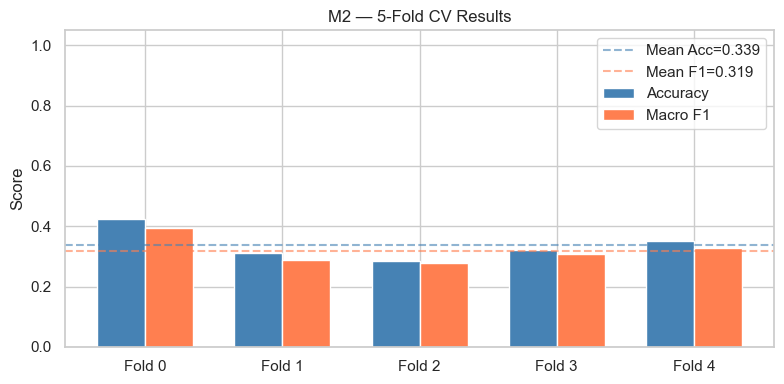

In [4]:

##── Per-fold results ──────────────────────────────────────────────────────────
plot_fold_results(results)
plt.savefig(ROOT / 'results/reports/M2_fold_results.png', dpi=150, bbox_inches='tight')
plt.show()


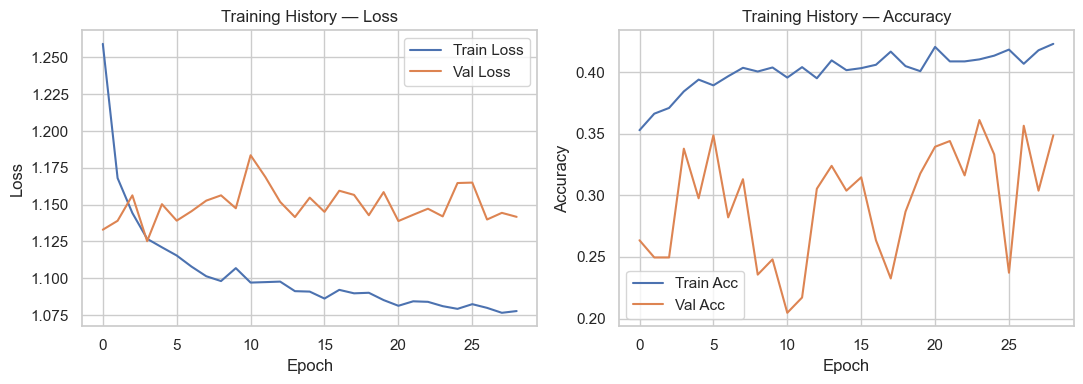

In [5]:
# ── Training history — Fold 0 ─────────────────────────────────────────────────
hist_fold0 = results['folds'][0].get('history')
if hist_fold0:
    plot_training_history(hist_fold0)
    plt.savefig(ROOT / 'results/reports/M2_history_fold0.png', dpi=150)
    plt.show()

In [6]:
# ── Confusion matrix (aggregate) ──────────────────────────────────────────────
all_true, all_pred = [], []
for fold in results['folds']:
    if 'y_true' in fold and 'y_pred' in fold:
        all_true.extend(fold['y_true'])
        all_pred.extend(fold['y_pred'])

if all_true:
    plot_confusion_matrix(np.array(all_true), np.array(all_pred),
                          class_names=CLASS_NAMES, title='M2 — Confusion Matrix (all folds)')
    plt.savefig(ROOT / 'results/reports/M2_confusion_matrix.png', dpi=150)
    plt.show()

TypeError: plot_confusion_matrix() got an unexpected keyword argument 'class_names'

In [17]:

# ── Per-fold table ────────────────────────────────────────────────────────────
rows = [{'Fold': i,
         'Accuracy': f.get('accuracy', float('nan')),
         'Macro-F1': f.get('macro_f1', float('nan'))}
        for i, f in enumerate(results['folds'])]
df = pd.DataFrame(rows)
df.loc['Mean'] = df.mean(numeric_only=True)
df.loc['Std']  = df.std(numeric_only=True)
df.style.format({'Accuracy': '{:.4f}', 'Macro-F1': '{:.4f}'})


,Fold,Accuracy,Macro-F1
0,0.000000,nan,nan
1,1.000000,nan,nan
2,2.000000,nan,nan
3,3.000000,nan,nan
4,4.000000,nan,nan
Mean,2.000000,nan,nan
Std,1.414214,nan,nan


In [18]:

# ── Save results to JSON for notebook 10 ─────────────────────────────────────
import json, numpy as np

def _to_serializable(obj):
    if isinstance(obj, (np.integer,)):  return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, np.ndarray):     return obj.tolist()
    if isinstance(obj, dict):           return {k: _to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, list):           return [_to_serializable(i) for i in obj]
    return obj

save_path = ROOT / 'results' / 'reports' / f'{MODEL_NAME}_results.json'
with open(save_path, 'w') as f:
    json.dump(_to_serializable(results), f, indent=2)
print(f'Saved → {save_path}')


Saved → C:\Users\raka1005\Documents\IISC\driver-drowsiness-detection-system\results\reports\M2_results.json
